# 母婴电商购物行为分析

**数据来源**：阿里云天池 · 淘宝母婴购物数据集（Baby Goods Info Data）

**分析目标**：在一个真实的电商交易数据集上，完成从数据质量体检、业务指标分析、
可视化到机器学习建模的完整链路。

**使用说明**：本 notebook 直接调用 `src/` 下的模块，与 `scripts/run_all.py` 保持同一套逻辑，
所有结果可复现。

---

## 0. 环境准备

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# 让 notebook 能 import 到 src 包
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import analysis, data_loader, modeling, preprocess, visualize
from src.config import FIGURE_DIR, TABLE_DIR, apply_style

apply_style()
pd.set_option("display.unicode.east_asian_width", True)
pd.set_option("display.max_columns", 50)

from IPython.display import Image, display


def show(path):
    # 重新加载 PNG 显示（绘图函数内部会关闭 figure，因此不能依赖 inline 输出）
    display(Image(filename=str(path)))


print("工作目录:", ROOT)

工作目录: C:\Users\Administrator\WorkBuddy\2026-10-08-07-53-07\mum-baby-analysis


---

## 1. 数据加载与质量体检

分析的第一步不是算指标，而是**搞清楚这份数据能回答什么问题**。

In [2]:
trade_raw = data_loader.load_trade()
baby_raw = data_loader.load_baby()

print(f"交易明细：{trade_raw.shape[0]:,} 行 × {trade_raw.shape[1]} 列")
print(f"宝宝信息：{baby_raw.shape[0]:,} 行 × {baby_raw.shape[1]} 列")
trade_raw.head()

交易明细：29,971 行 × 7 列
宝宝信息：953 行 × 3 列


,user_id,auction_id,cat_id,cat1,property,buy_mount,day
0,786295544,41098319944,50014866,50022520,21458:86755362;13023209:3593274;10984217:21985...,2,2014-09-19
1,532110457,17916191097,50011993,28,21458:11399317;1628862:3251296;21475:137325;16...,1,2013-10-11
2,249013725,21896936223,50012461,50014815,21458:30992;1628665:92012;1628665:3233938;1628...,1,2013-10-11
3,917056007,12515996043,50018831,50014815,21458:15841995;21956:3494076;27000458:59723383...,2,2014-10-23
4,444069173,20487688075,50013636,50008168,21458:30992;13658074:3323064;1628665:3233941;1...,1,2014-11-03


In [3]:
quality = data_loader.quality_report(trade_raw, baby_raw)
quality

,检查项,结果,说明
0,交易表行数,29971,
1,交易表用户数,29944,
2,交易表商品数,28422,
3,交易表时间跨度,2012-07-02 ~ 2015-02-05,
4,交易表日期缺失,0,
5,交易表属性为空,144,property 字段无内容
6,交易表购买量异常(<=0),0,
7,宝宝表行数,953,
8,宝宝表生日缺失,0,
9,宝宝表性别分布,0:489 / 1:438 / 2:26,0=女宝 1=男宝 2=未知（天池官方说明）


### 1.1 关键判断：这是一份「按行抽样」的数据

从体检表可以看到：**29,971 笔交易对应 29,944 个用户，人均仅 1.0009 笔**，只有 25 个用户有复购。

这意味着这份样本不是用户行为序列，而是随机抽取的交易行。由此得出一个重要的分析边界：

> **不能做**：RFM 分层、复购周期、用户生命周期、基于用户行为序列的性别预测
> **可以做**：交易分析、品类结构、时间趋势、商品属性、宝宝画像

主动划清边界，比硬做出一堆无效结论更有价值。

---

## 2. 数据清洗与特征工程

In [4]:
pack = preprocess.run(trade_raw, baby_raw)

trade = pack["trade"]           # 交易明细 + 时间特征 + 属性特征
baby = pack["baby"]             # 宝宝档案
user_profile = pack["user_profile"]   # 宝宝档案 ⋈ 交易聚合

print(f"清洗后交易：{len(trade):,} 行")
print(f"宝宝档案：{len(baby):,} 行")
print(f"用户画像：{len(user_profile):,} 行")
trade[["user_id", "cat1_name", "buy_mount", "day", "year_month",
       "weekday_name", "is_promo", "n_props", "is_bulk"]].head()

清洗后交易：29,971 行
宝宝档案：952 行
用户画像：810 行


,user_id,cat1_name,buy_mount,day,year_month,weekday_name,is_promo,n_props,is_bulk
0,786295544,喂养/洗护,2,2014-09-19,2014-09,周五,False,10,False
1,532110457,尿裤/湿巾,1,2013-10-11,2013-10,周五,False,11,False
2,249013725,童装/童鞋,1,2013-10-11,2013-10,周五,False,2,False
3,917056007,童装/童鞋,2,2014-10-23,2014-10,周四,False,10,False
4,444069173,奶粉/辅食,1,2014-11-03,2014-11,周一,False,14,False


---

## 3. 时间维度分析

### 3.1 月度趋势

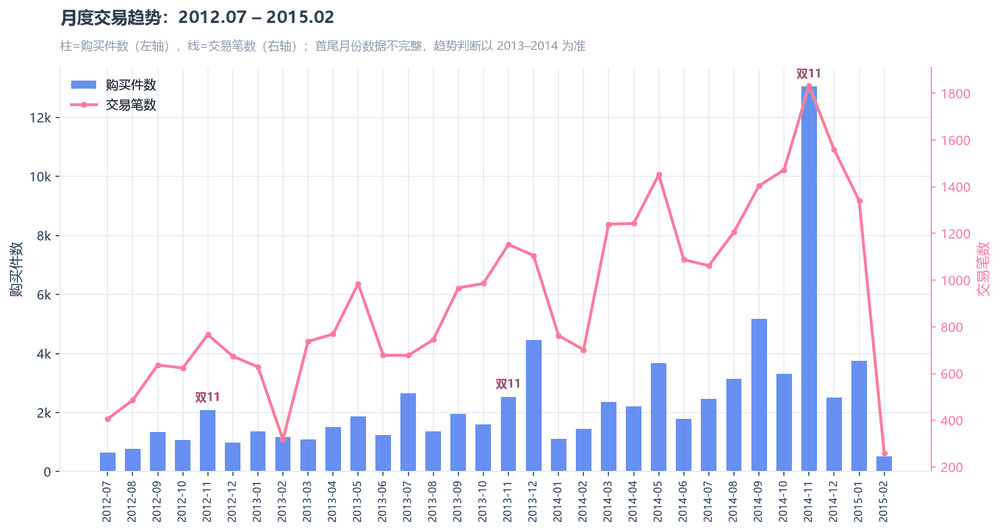

,year_month,交易笔数,购买件数,活跃用户
20,2014-03,1240,2359,1240
21,2014-04,1243,2204,1243
22,2014-05,1452,3669,1452
23,2014-06,1088,1785,1088
24,2014-07,1062,2461,1062
25,2014-08,1206,3139,1206
26,2014-09,1404,5185,1403
27,2014-10,1472,3320,1471
28,2014-11,1833,13044,1833
29,2014-12,1559,2508,1559


In [5]:
monthly = analysis.monthly_trend(trade)
show(visualize.plot_monthly_trend(monthly))
monthly.tail(12)[["year_month", "交易笔数", "购买件数", "活跃用户"]]

### 3.2 季节性：只在数据完整的年度内比较

2012 年只有 7–12 月数据、2015 年只有 1–2 月数据，直接做行归一化会产生
「2015 年 1 月占全年 88%」的假象。因此只使用 2013–2014 两个完整年度。

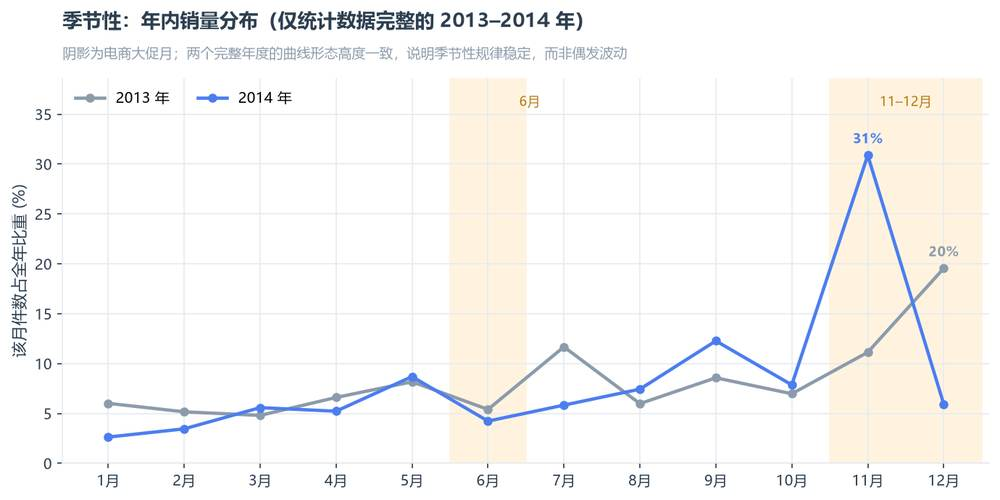

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2013,6.0,5.2,4.8,6.6,8.2,5.4,11.7,6.0,8.6,7.0,11.1,19.5
2014,2.6,3.4,5.6,5.2,8.7,4.2,5.8,7.4,12.3,7.9,30.9,5.9


In [6]:
share = analysis.monthly_share_by_year(trade)
show(visualize.plot_seasonality(share))
share.round(1)

### 3.3 大促拉动效果

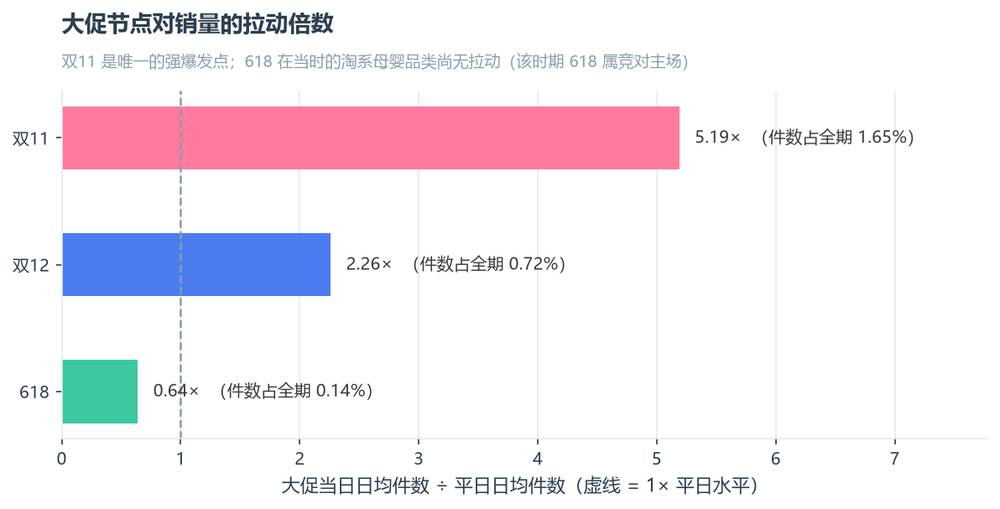

,大促,覆盖天数,总件数,大促日均件数,平日日均件数,拉动倍数,件数占全期比重(%)
0,双11,3,1250,416.7,80.2,5.19,1.65
1,双12,3,544,181.3,80.2,2.26,0.72
2,618,2,103,51.5,80.2,0.64,0.14


In [7]:
promo = analysis.promo_effect(trade)
show(visualize.plot_promo(promo))
promo

**结论**：双11 拉动 5.19 倍、双12 拉动 2.26 倍，而 **618 只有 0.64 倍**（低于平日）。

在 2012–2014 年的淘系母婴品类中，618 尚未形成大促心智。这提醒我们：
**行业常识需要被数据验证，不能直接照搬**。

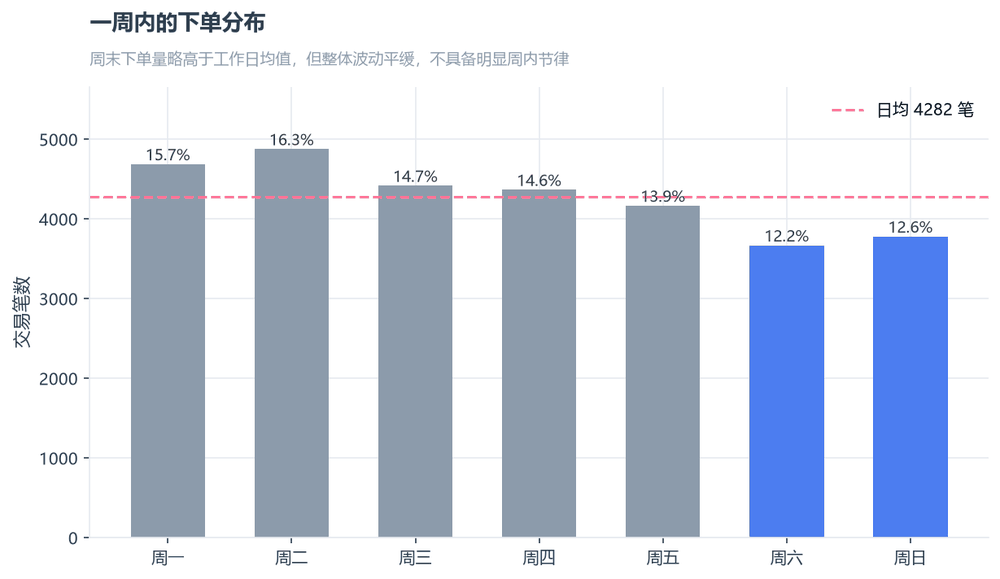

,日期,星期,交易笔数,购买件数
0,2014-11-13,周四,49,10061
1,2013-12-20,周五,35,2841
2,2014-09-20,周六,45,2804
3,2015-01-12,周一,45,1552
4,2013-07-01,周一,26,1032
5,2014-10-21,周二,50,804
6,2014-11-11,周二,454,774
7,2014-07-02,周三,38,645
8,2013-02-22,周五,20,631
9,2014-10-07,周二,44,568


In [8]:
show(visualize.plot_weekday(analysis.weekday_distribution(trade)))
analysis.top_promo_days(trade, 10)

---

## 4. 品类结构分析

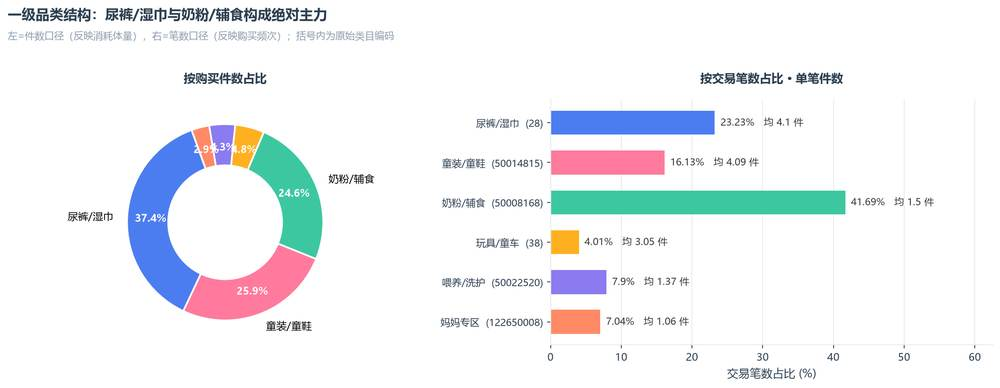

,品类,交易笔数,购买件数,商品数,笔数占比(%),件数占比(%),单笔平均件数
0,尿裤/湿巾,6963,28545,6580,23.23,37.44,4.10
1,童装/童鞋,4834,19763,4457,16.13,25.92,4.09
2,奶粉/辅食,12494,18792,12046,41.69,24.65,1.50
3,玩具/童车,1203,3666,1176,4.01,4.81,3.05
4,喂养/洗护,2367,3245,2115,7.90,4.26,1.37
5,妈妈专区,2110,2239,2048,7.04,2.94,1.06


In [9]:
cat1 = analysis.category_breakdown(trade, "cat1_name")
show(visualize.plot_cat1_share(cat1))
cat1

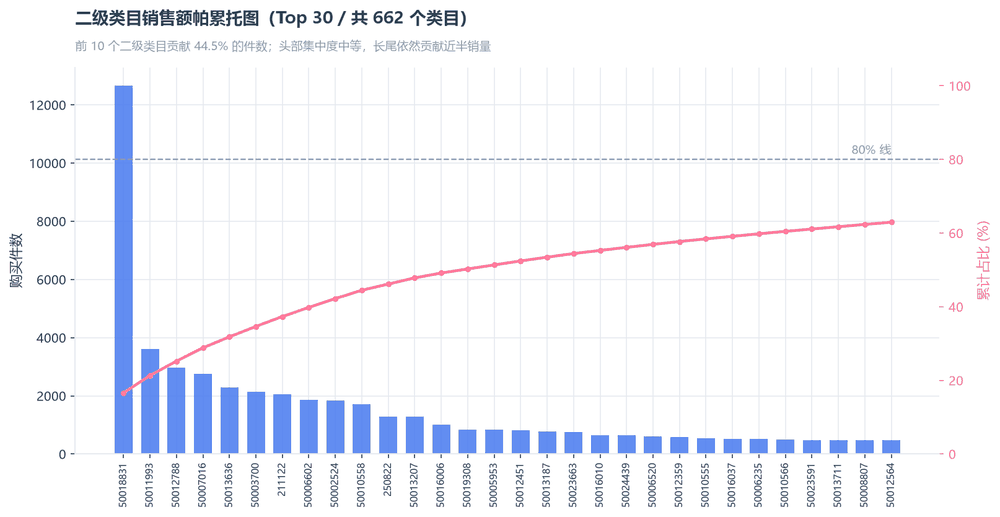

,指标,数值
0,CR5（前5类目件数占比）,31.83%
1,CR10,44.47%
2,CR20,56.13%
3,类目总数,662
4,HHI（赫芬达尔指数）,394.8
5,贡献后50%件数的类目数,14


In [10]:
pareto = analysis.category_pareto(trade, "cat_id")
show(visualize.plot_pareto(pareto))
analysis.concentration_metrics(pareto)

**结论**：CR10 = 44.5%、HHI = 394.8，属于「中等集中度 + 长尾厚」的结构。
头部没有绝对垄断品类，662 个二级类目中的长尾依然贡献近半销量。

---

## 5. 购买量分布与异常订单识别

### 5.1 购买量分布

In [11]:
analysis.buy_mount_stats(trade)

,指标,数值
0,平均数,2.54
1,中位数,1.00
2,众数,1.00
3,标准差,63.99
4,P90,2.00
5,P99,13.00
6,最大值,10000.00
7,单件购买占比(%),87.87
8,囤货(≥3件)占比(%),6.13
9,偏度,133.46


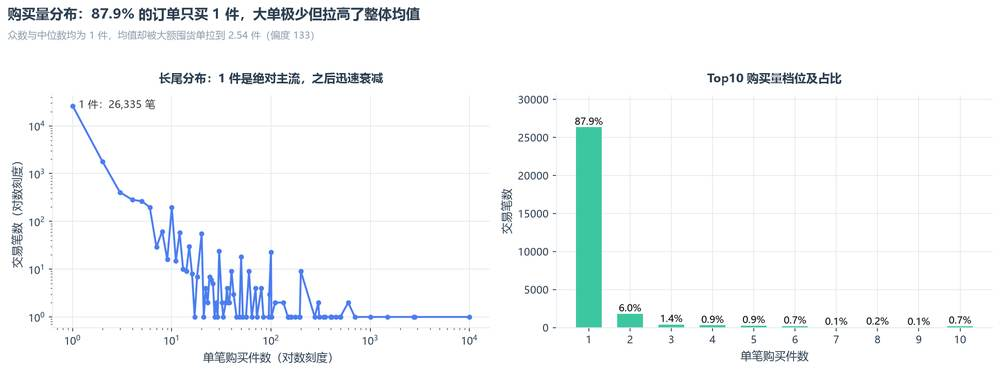

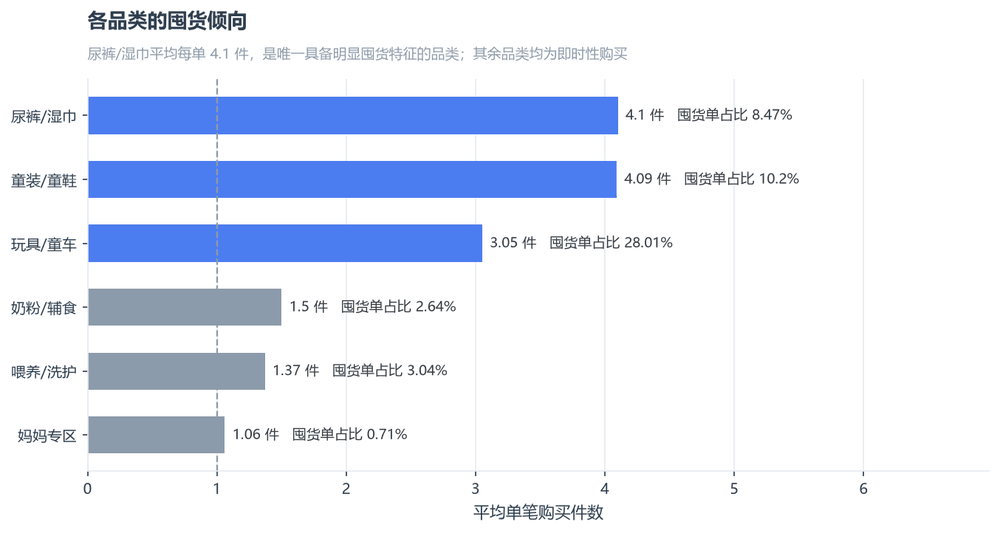

In [12]:
show(visualize.plot_buy_mount_dist(trade))
show(visualize.plot_bulk_by_cat(analysis.bulk_by_category(trade)))

### 5.2 异常订单识别（本项目最重要的数据质量发现）

购买量最大值达到 10,000 件，明显不属于正常消费行为。需要量化它对整体指标的影响。

In [13]:
top_orders = analysis.outlier_orders(trade, 10)
top_orders

,排名,user_id,auction_id,cat1_name,buy_mount,日期,占全部件数比重(%),累计占比(%)
0,1,2288344467,39769942518,童装/童鞋,10000,2014-11-13,13.11,13.11
1,2,117730165,20409520643,尿裤/湿巾,2800,2013-12-20,3.67,16.78
2,3,173701616,36505037679,奶粉/辅食,2748,2014-09-20,3.60,20.38
3,4,1945590674,3920805463,尿裤/湿巾,1500,2015-01-12,1.97,22.35
4,5,32141414,9716351898,尿裤/湿巾,1000,2013-07-01,1.31,23.66
5,6,119395773,21753712913,尿裤/湿巾,700,2014-10-21,0.92,24.58
6,7,300205516,8728039815,尿裤/湿巾,600,2013-02-22,0.79,25.37
7,8,300857121,38276597770,尿裤/湿巾,600,2014-07-02,0.79,26.16
8,9,462029374,7398446291,尿裤/湿巾,500,2012-11-19,0.66,26.82
9,10,1671630112,41020683325,尿裤/湿巾,498,2014-10-07,0.65,27.47


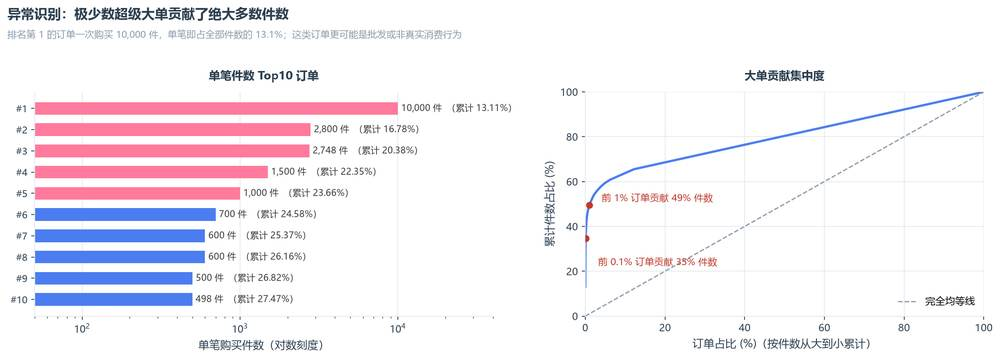

,指标,数值
0,全部订单平均单笔件数,2.54
1,剔除 Top10 大单后的平均单笔件数,1.85
2,Top10 大单合计件数,20946
3,Top10 大单占全部件数比重,27.5%
4,Top10 大单笔数占比,0.033%
5,最大单笔件数,10000
6,最大单笔所属品类,童装/童鞋
7,最大单笔日期,2014-11-13


In [14]:
impact = analysis.outlier_impact(trade, 10)
show(visualize.plot_outliers(top_orders, analysis.long_tail_curve(trade)))
impact

**结论**：单笔最大 10,000 件（童装/童鞋），一笔即占全部件数的 **13.1%**；Top10 大单合计占 **27.5%**。

- 剔除 Top10 大单后，平均单笔件数从 **2.54 件 → 1.85 件**
- 这类订单更可能是批发或非真实消费行为
- 建议核心 KPI 改用**订单数 / 用户数**为主口径

---

## 6. 宝宝画像与品类偏好

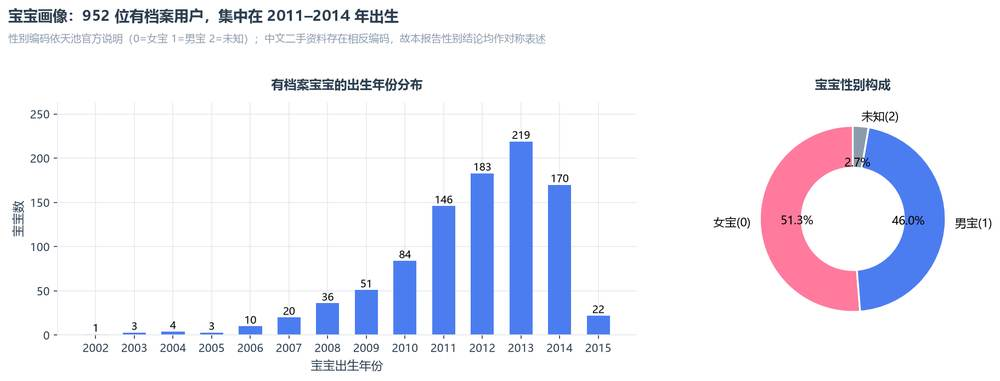

In [15]:
show(visualize.plot_baby_profile(analysis.baby_birth_year(baby), baby))

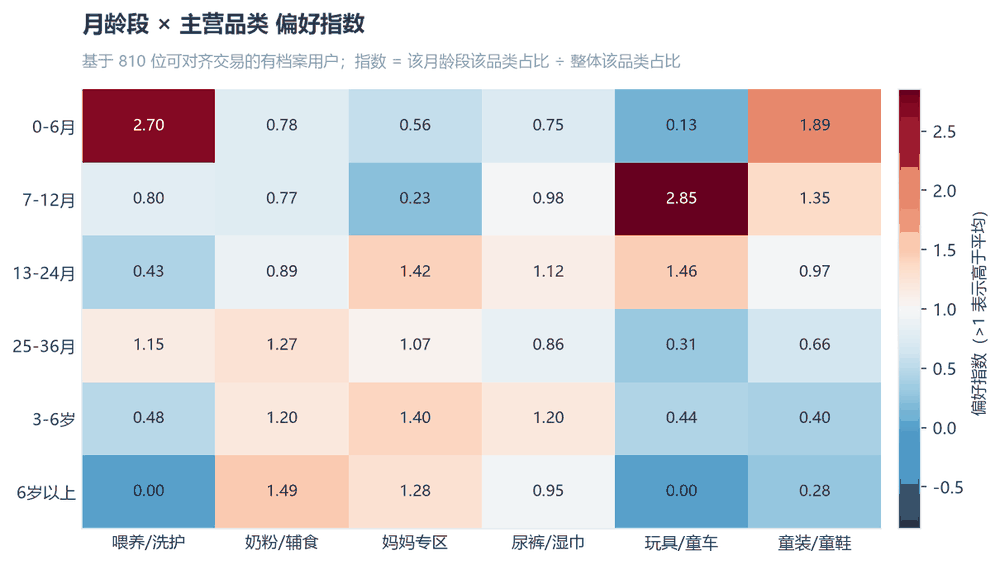

主营品类,喂养/洗护,奶粉/辅食,妈妈专区,尿裤/湿巾,玩具/童车,童装/童鞋
age_stage,,,,,,
0-6月,2.70,0.78,0.56,0.75,0.13,1.89
7-12月,0.80,0.77,0.23,0.98,2.85,1.35
13-24月,0.43,0.89,1.42,1.12,1.46,0.97
25-36月,1.15,1.27,1.07,0.86,0.31,0.66
3-6岁,0.48,1.20,1.40,1.20,0.44,0.40
6岁以上,0.00,1.49,1.28,0.95,0.00,0.28


In [16]:
lift = analysis.age_category_correlation(user_profile)
counts = analysis.age_stage_preference(user_profile)
show(visualize.plot_age_category(lift, counts))
lift

**结论**：月龄是有效的偏好维度 —— 7–12 月龄的玩具偏好指数达 2.85，
0–6 月龄的洗护偏好指数达 2.70，6 岁以上仍可推成长奶粉（1.49）。

### 6.1 性别与品类偏好：卡方独立性检验

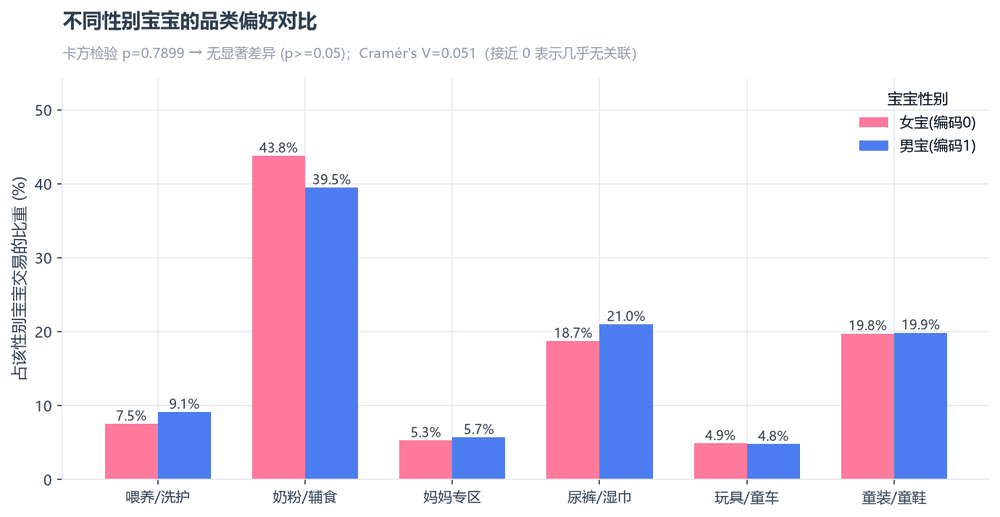

,指标,数值
0,卡方统计量,2.41
1,自由度,5
2,p 值,0.7899
3,结论,无显著差异 (p>=0.05)
4,Cramér's V（效应量）,0.051
5,样本量,929


In [17]:
trade_with_baby = trade.merge(
    baby[["user_id", "gender", "gender_name"]], on="user_id", how="inner")

ct, chi2_res = analysis.gender_category_test(trade_with_baby)
show(visualize.plot_gender_category(ct, chi2_res))
chi2_res

**结论：无显著差异**。p = 0.79（远大于 0.05），Cramér's V = 0.051（效应量接近 0）。

这是一个「没有差异」的结论，但它同样有价值：它直接否定了
**「按宝宝性别做差异化推荐」**这一运营假设，避免把资源投在无效维度上。

---

## 7. 商品属性挖掘

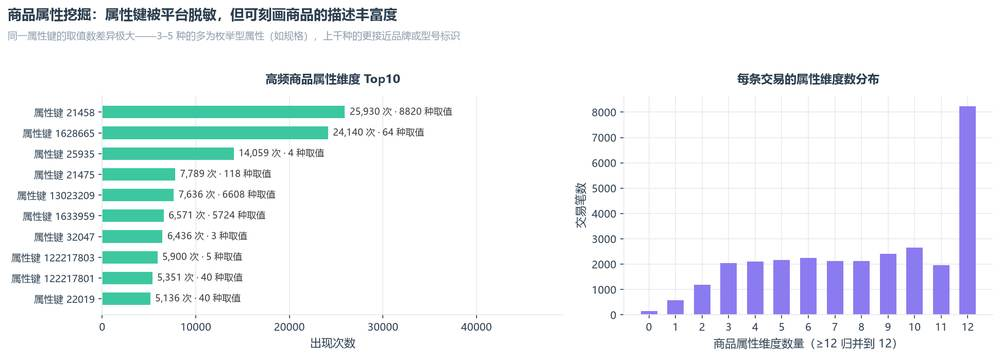

,指标,数值
0,无属性记录的交易占比(%),0.48
1,平均属性维度数,8.68
2,属性维度数中位数,9.00
3,属性维度数最大值,21.00


In [18]:
show(visualize.plot_property(
    analysis.property_value_diversity(pack["kv_detail"], pack["key_freq"]),
    trade,
))
analysis.property_stats(trade)

属性键与取值均被平台脱敏，无法还原「品牌/尺码」等具体语义。
但**属性维度数**本身携带了「商品描述丰富度」这一信号，
并在后续建模中成为最重要的特征。

---

## 8. 机器学习：囤货订单识别

### 8.1 为什么不做经典的「性别预测」？

天池该数据集最经典的赛题是用购买行为预测宝宝性别，但那需要**单个用户的多条记录**。
先实测一下这份数据能否支撑该任务。

In [19]:
feasibility = modeling.evaluate_gender_feasibility(trade, baby)
feasibility

,指标,数值
0,有性别标签的用户数,929
1,人均可用的交易记录数,1.0
2,性别预测 ROC-AUC,0.4931
3,随机基线 AUC,0.5
4,结论,接近随机水平，该抽样结构不支持性别预测建模
5,原因,每位标签用户仅有约 1 条行为记录，无法构造用户级行为特征...


实测 **ROC-AUC = 0.4931**，与随机猜测（0.5）无异，验证了前面的判断。
因此转向数据能够支撑的任务。

### 8.2 正式任务：预测订单是否会囤货（购买 ≥ 3 件）

In [20]:
result = modeling.run_bulk_model(trade)
result["summary"]

,指标,数值
0,样本量,29971
1,正类（囤货单）占比,6.13%
2,特征维度,44
3,最优模型,逻辑回归
4,ROC-AUC (5折CV),0.7782
5,PR-AUC (5折CV),0.2101
6,最佳概率阈值,0.709
7,"混淆矩阵 [[TN,FP],[FN,TP]]","[[26060, 2074], [1271, 566]]"


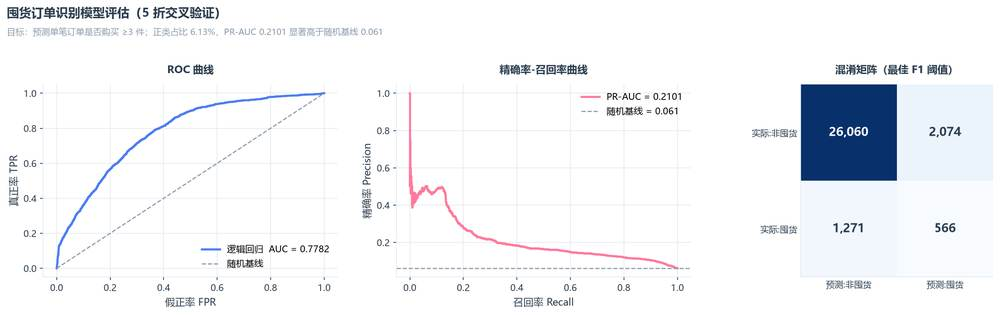

,模型,ROC-AUC,PR-AUC
0,逻辑回归,0.7782,0.2101
1,随机森林,0.7737,0.2083


In [21]:
show(visualize.plot_model_results(result))
result["model_comparison"]

In [22]:
result["report"]

,precision,recall,f1-score,support
类别,,,,
0,0.953,0.926,0.940,28134.000
1,0.214,0.308,0.253,1837.000
accuracy,0.888,0.888,0.888,0.888
macro avg,0.584,0.617,0.596,29971.000
weighted avg,0.908,0.888,0.898,29971.000


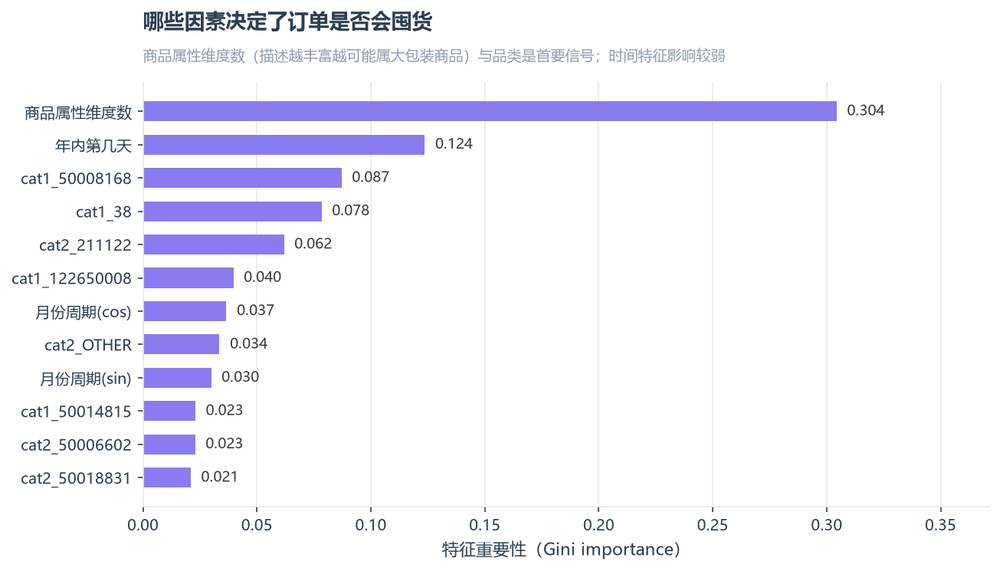

,特征,重要性
0,商品属性维度数,0.304358
1,年内第几天,0.123645
2,cat1_50008168,0.087112
3,cat1_38,0.078341
4,cat2_211122,0.061859
5,cat1_122650008,0.039649
6,月份周期(cos),0.036616
7,cat2_OTHER,0.033591
8,月份周期(sin),0.029914
9,cat1_50014815,0.022981


In [23]:
show(visualize.plot_feature_importance(result["importance"]))
result["importance"].head(10)

**结论**：5 折交叉验证下 ROC-AUC = 0.778、PR-AUC = 0.210（随机基线 0.061，提升 3.4 倍）。

- 首要预测信号是**商品属性维度数**（重要性 0.304），即商品描述越丰富越可能是大包装
- 时间特征影响有限，说明囤货更多由「买什么」而非「什么时候买」决定
- 逻辑回归略优于随机森林，最终选择更简单、更可解释的模型

---

## 9. 小结

| 分析方向 | 核心结论 |
| :--- | :--- |
| 时间维度 | 2014 年件数同比 +19.9%；双11 拉动 5.19 倍；618 无拉动；11 月占全年约 31% |
| 品类结构 | 尿裤/湿巾贡献 37.4% 件数（单笔 4.1 件）；奶粉贡献 41.7% 笔数（单笔 1.5 件）；CR10 = 44.5% |
| 购买量 | 87.9% 订单只买 1 件，极端长尾（偏度 133） |
| 异常识别 | 0.03% 订单贡献 27.5% 件数，最大单笔 10,000 件 |
| 宝宝画像 | 月龄显著影响品类偏好；性别无显著影响（p=0.79） |
| 机器学习 | 囤货预测 ROC-AUC 0.778、PR-AUC 0.210 |

**完整图表与报告**：见 `reports/report.html`